# [Deep Agents - Middleware](https://docs.langchain.com/oss/python/deepagents/middleware)

Deep Agents의 미들웨어 아키텍처를 활용하여 토큰 사용량과 실행 시간을 추적하는 시스템을 구축합니다.
이를 통해 에이전트의 성능을 모니터링하고 비용을 최적화할 수 있습니다.


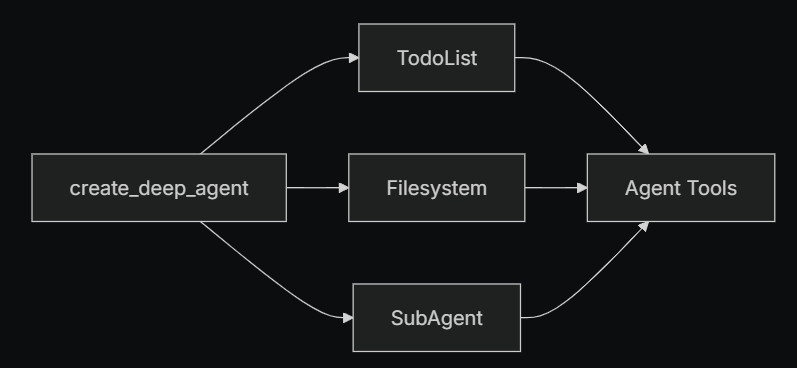

## Middleware란?

애플리케이션의 핵심 로직을 수정하지 않고도 공통 기능이나 동작 방식을 중간 계층에서 주입하는 구조를 의미한다.

웹 서버 예시:
- 인증 미들웨어
- 로깅 미들웨어
- 트랜잭션 관리 미들웨어

## DeepAgents에서의 Middleware

DeepAgents에서 Middleware는 에이전트의 사고 방식과 행동 패턴을 확장하는 구성 요소다.
- 에이전트의 코어 로직은 그대로 유지
- 추가적인 도구(tools), 규칙, 시스템 프롬프트를 주입
- 에이전트가 “어떻게 행동해야 하는지”를 구조적으로 정의

> 즉, 에이전트를 직접 고치지 않고도 새로운 능력을 부여하는 방법이다.

## 메트릭 추적 미들웨어 예제 

### Setup

#### 환경 변수 설정
- [OpenAI API Key](https://platform.openai.com/api-keys)
- [Tavily API Key](https://tavily.com/) - 웹 검색용
- [LangSmith API Key](https://smith.langchain.com/)

In [1]:
from dotenv import load_dotenv

# 환경 변수 로드
load_dotenv()

True

#### LLM 정의 

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini"
)


## TodoListMiddleware

In [3]:
from langchain.agents.middleware import TodoListMiddleware

todo_middleware = TodoListMiddleware(
    system_prompt="""
너는 사용자의 목표를 분석해서
1) 단계별 할 일(To-Do List)을 만들고
2) 하나씩 수행하면서
3) 완료한 항목은 완료 처리해야 한다.

반드시 write_todos 도구를 사용해서
할 일을 관리해라.
"""
)

### create_deep_agent

In [12]:
from langchain.agents import create_agent

agent_with_middleware = create_agent(
    model=llm,  # 예시 모델
    middleware=[todo_middleware],
)

### test

In [13]:
user_goal = """
LangChain과 DeepAgents를 처음 배우는 학생을 위해
3일짜리 학습 계획을 만들어줘.
"""

result = agent_with_middleware.invoke({
    "messages": [
        {"role": "user", "content": user_goal}
    ]
})

print("===== 최종 결과 =====")
print(result['messages'][-1].content)


===== 최종 결과 =====
모든 작업을 완료했습니다! 🎉

### 3일짜리 학습 계획 요약:
1. **LangChain과 DeepAgents의 기초 개념 이해하기** - 완료
2. **LangChain 설치 및 기본 사용법 익히기** - 완료
3. **DeepAgents 설치 및 간단한 예제 실행해보기** - 완료
4. **LangChain의 다양한 기능 실습하기 (예: API 연결, 데이터 저장 등)** - 완료
5. **DeepAgents의 주요 기능 및 활용 사례 공부하기** - 완료
6. **LangChain과 DeepAgents의 프로젝트 통합 방법 탐색하기** - 완료
7. **마무리 및 느낀 점 정리하기** - 완료

이렇게 잘 마무리된 학습 계획이 도움이 되었기를 바랍니다! 추가적인 질문이나 더 필요한 정보가 있다면 언제든지 말씀해 주세요. 😊


## SubAgentMiddleware

### Tools

In [ ]:
from langchain_tavily import TavilySearch

# Tavily 검색 도구 설정
tavily_search_weather = TavilySearch(
    max_results=3,
    search_depth="advanced",
    include_answer=True,
    include_raw_content=False,
    include_domains=[
        "https://weather.naver.com/",
        "https://weather.daum.net/",
        "https://www.accuweather.com/" 
    ],
    exclude_domains=None            # 필요하면 제외 도메인 지정 가능
)

In [ ]:
from langchain.tools import tool

@tool
def get_weather(city: str) -> str:
    """간단한 날씨 조회 예제: 도시 이름을 받아서 응답 문자열 반환"""
    try:
        # Tavily로 검색
        results = tavily_search_weather.invoke(city)
        
        if not results:
            return f"'{city}'에 대한 날씨 정보를 찾을 수 없습니다."
        
        # 결과 요약
        summary = f"=== '{city}' 조사 결과 ===\n\n"
        summary += f"총 {len(results['results'])}개의 참고 자료를 수집했습니다.\n\n"
        
        for idx, result in enumerate(results['results'], 1):
            title = result.get('title', '제목 없음')
            content = result.get('content', '')
            url = result.get('url', '')
            
            summary += f"{idx}. [{title}]\n"
            summary += f"   {content[:300]}...\n"
            summary += f"   출처: {url}\n\n"
        
        return summary
    except Exception as e:
        return f"조사 중 오류 발생: {str(e)}"

In [23]:
from deepagents.middleware.subagents import SubAgentMiddleware

subagent_middleware = SubAgentMiddleware(
    default_model=llm,  # 기본 모델
    default_tools=[get_weather],              # 기본 도구
    task_description="도시 이름을 받아 날씨 정보를 조사하는 에이전트입니다.",
    system_prompt="""
너는 날씨 정보를 전문적으로 조사하는 에이전트입니다.
get_weather 도구를 사용해서 답을 작성하세요.
"""
)

### create_deep_agent

In [24]:
from langchain.agents import create_agent

agent_with_subagent_middleware = create_agent(
    model=llm,
    middleware=[subagent_middleware],
)

### test

In [25]:
user_goal = """
부산 날씨를 알려줘.
"""

result = agent_with_subagent_middleware.invoke({
    "messages": [
        {"role": "user", "content": user_goal}
    ]
})

print("=== 최종 결과 ===")
print(result['messages'][-1].content)


=== 최종 결과 ===
부산의 현재 날씨는 다음과 같습니다:

- **상태**: 화창
- **온도**: 약 34°C (체감 온도 23°C)
- **바람**: 북서쪽에서 시속 16.1km (최대 돌풍: 53km/h)
- **습도**: 21%
- **대기질**: 나쁨
- **구름 상태**: 구름 없음
- **가시 거리**: 16km
- **자외선 지수**: 낮음 (2.3)

현재 건조 주의보가 발효 중입니다. 날씨에 유의하시기 바랍니다!


# [Deep Agents - Callback Handler](https://reference.langchain.com/python/langchain_core/callbacks/)

Callback Handler는 어떤 작업이 “시작 / 진행 / 종료”되는 시점에 자동으로 호출되는 훅(hook)입니다.

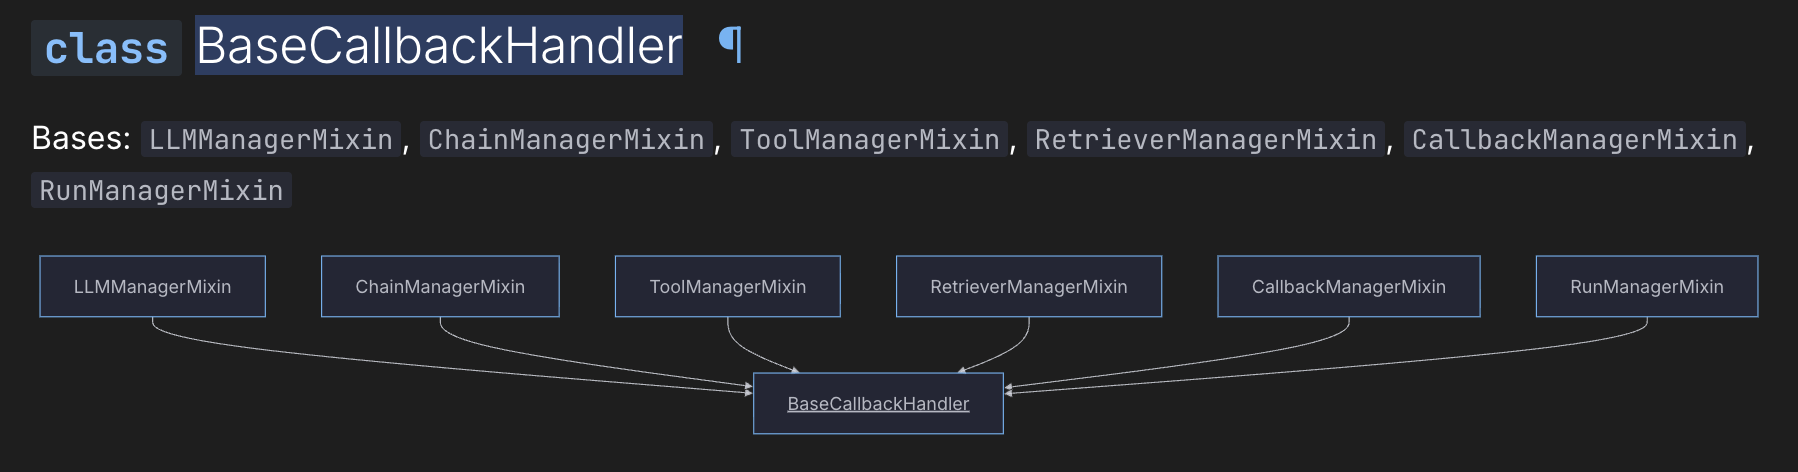

## Middleware vs Callback Handler

> Callback Handler는 “실행을 방해하지 않는 관찰자”이고, Middleware는 “실행 흐름을 통제하는 관리자”다.

| 구분           | Middleware | Callback Handler |
| ------------ | ---------- | ---------------- |
| 개입 시점        | 요청 전/후     | 이벤트 발생 시         |
| 흐름 제어        | 가능         | 불가               |
| 입력/출력 수정     | 가능         | 불가               |
| 주요 목적        | 제어, 정책     | 관찰, 로깅           |
| 예시           | 인증, 캐시     | 토큰 출력, tracing   |


## Tools 정의 

In [30]:
from langchain_tavily import TavilySearch

# Tavily 검색 도구 설정
tavily_research_topic = TavilySearch(
    max_results=5,
    search_depth="advanced",
    include_answer=True,
    include_raw_content=False,
)

In [31]:
from langchain.tools import tool

@tool
def research_topic(topic: str) -> str:
    """Tavily를 사용하여 주제를 깊이 조사하는 도구
    
    Args:
        topic: 조사할 주제
        
    Returns:
        상세한 조사 결과
    """
    try:
        # Tavily로 검색
        results = tavily_research_topic.invoke(topic)
        
        if not results:
            return f"'{topic}'에 대한 정보를 찾을 수 없습니다."
        
        # 결과 요약
        summary = f"=== '{topic}' 조사 결과 ===\n\n"
        summary += f"총 {len(results['results'])}개의 참고 자료를 수집했습니다.\n\n"
        
        for idx, result in enumerate(results['results'], 1):
            title = result.get('title', '제목 없음')
            content = result.get('content', '')
            url = result.get('url', '')
            
            summary += f"{idx}. [{title}]\n"
            summary += f"   {content[:300]}...\n"
            summary += f"   출처: {url}\n\n"
        
        return summary
    except Exception as e:
        return f"조사 중 오류 발생: {str(e)}"

In [32]:
@tool
def analyze_data(query: str) -> str:
    """LLM을 사용하여 데이터를 분석하는 도구
    
    Args:
        query: 분석할 내용이나 질문
        
    Returns:
        분석 결과 및 인사이트
    """
    try:
        # LLM에게 분석 요청
        analysis_prompt = f"""
다음 주제에 대해 데이터 분석가의 관점에서 심층 분석을 수행하세요:

{query}

다음 항목을 포함하여 분석해주세요:
1. 주요 트렌드 및 패턴
2. 핵심 인사이트 (3가지)
3. 시사점 및 의미
4. 향후 전망

간결하고 명확하게 작성해주세요."""
        
        response = llm.invoke(analysis_prompt)
        return f"=== 데이터 분석 결과 ===\n\n{response.content}"
    except Exception as e:
        return f"분석 중 오류 발생: {str(e)}"
        

In [35]:
import os 

@tool
def create_report(title: str, content: str) -> str:
    """수집된 정보를 바탕으로 구조화된 리포트를 생성하는 도구
    
    Args:
        title: 리포트 제목
        content: 리포트에 포함할 내용
        
    Returns:
        생성된 리포트
    """
    try:
        # LLM에게 리포트 작성 요청
        report_prompt = f"""
다음 정보를 바탕으로 '{title}'이라는 제목의 전문적인 리포트를 작성하세요:

{content}

리포트 구성:
1. 개요 (Executive Summary)
2. 주요 내용 (3-4개 섹션으로 구성)
3. 결론 및 제언

전문적이고 읽기 쉬운 형식으로 작성해주세요."""
        
        response = llm.invoke(report_prompt)
        
        # 리포트 저장
        filename = f"{title.replace(' ', '_')}.md"
        filepath = os.path.join(os.getcwd(), filename)
        
        report_content = f"# {title}\n\n{response.content}"
        
        with open(filepath, 'w', encoding='utf-8') as f:
            f.write(report_content)
        
        return f"=== 리포트 생성 완료 ===\n\n{report_content}\n\n저장 위치: {filepath}"
    except Exception as e:
        return f"리포트 생성 중 오류 발생: {str(e)}"


## Deep Agent 생성 (Tavily + LLM 도구 사용)

In [36]:
from deepagents import create_deep_agent

# 실제 Deep Agent 생성 (Tavily + LLM 도구 사용)
real_agent = create_deep_agent(
    model=llm,
    tools=[research_topic, analyze_data, create_report],
    system_prompt="""당신은 효율적인 연구 및 분석 전문가입니다.
주어진 작업을 다음 단계로 수행하세요:

1. research_topic 도구로 주제를 조사합니다 (Tavily 웹 검색 사용)
2. analyze_data 도구로 수집한 데이터를 분석합니다 (LLM 분석)
3. create_report 도구로 최종 리포트를 작성합니다 (구조화된 문서)

각 단계를 명확하게 설명하고, 도구를 효율적으로 사용하세요.
실제 웹 검색과 LLM 분석을 통해 고품질의 결과물을 생성하세요.
"""
)

print("실제 Deep Agent 준비 완료")
print("\n포함된 기능:")
print("   - Tavily 웹 검색 (research_topic)")
print("   - LLM 데이터 분석 (analyze_data)")
print("   - LLM 리포트 생성 (create_report)")
print("   - CallbackHandler 기반 메트릭 추적")
print("\n주의: 실제 API를 호출하므로 비용이 발생합니다.")

실제 Deep Agent 준비 완료

포함된 기능:
   - Tavily 웹 검색 (research_topic)
   - LLM 데이터 분석 (analyze_data)
   - LLM 리포트 생성 (create_report)
   - CallbackHandler 기반 메트릭 추적

주의: 실제 API를 호출하므로 비용이 발생합니다.


## Callback Handler 생성 (LangChain 기반 메트릭 추적)

In [37]:
from langchain_core.callbacks import BaseCallbackHandler
from langchain_core.outputs import LLMResult
from typing import Any, Dict, List
from datetime import datetime


class MetricsCallbackHandler(BaseCallbackHandler):
    """LangChain CallbackHandler를 사용한 메트릭 추적
    
    Deep Agent의 LLM 호출과 도구 호출을 자동으로 추적합니다.
    """
    
    def __init__(self):
        super().__init__()
        self.metrics = {
            'total_tokens': 0,
            'prompt_tokens': 0,
            'completion_tokens': 0,
            'llm_calls': 0,
            'tool_calls': 0,
            'errors': 0,
            'start_time': datetime.now(),
            'tool_usage': {},
            'execution_times': [],
        }
        self.current_start_time = None
    
    def on_llm_start(self, serialized: Dict[str, Any], prompts: List[str], **kwargs: Any) -> None:
        """LLM 호출 시작"""
        print("[MetricsCallbackHandler][on_llm_start] LLM 호출 시작")

        self.metrics['llm_calls'] += 1
        self.current_start_time = datetime.now()
        print(f"\nLLM 호출 #{self.metrics['llm_calls']}")
    
    def on_llm_end(self, response: LLMResult, **kwargs: Any) -> None:
        """LLM 호출 완료"""
        print("[MetricsCallbackHandler][on_llm_end] LLM 호출 완료")

        elapsed = (datetime.now() - self.current_start_time).total_seconds() if self.current_start_time else 0
        
        # 토큰 사용량 추출
        print("[MetricsCallbackHandler][on_llm_end]  >> 토큰 사용량 추출")
        if response.llm_output and 'token_usage' in response.llm_output:
            token_usage = response.llm_output['token_usage']
            prompt_tokens = token_usage.get('prompt_tokens', 0)
            completion_tokens = token_usage.get('completion_tokens', 0)
            total_tokens = token_usage.get('total_tokens', 0)
            
            self.metrics['prompt_tokens'] += prompt_tokens
            self.metrics['completion_tokens'] += completion_tokens
            self.metrics['total_tokens'] += total_tokens
            
            # 비용 계산 (gpt-4o-mini: $0.150/1M input, $0.600/1M output)
            print("[MetricsCallbackHandler][on_llm_end]  >> 비용 계산(gpt-4o-mini)")
            cost = (prompt_tokens / 1_000_000) * 0.150 + (completion_tokens / 1_000_000) * 0.600
            
            print(f"LLM 응답 완료")
            print(f"   토큰: {prompt_tokens} (입력) + {completion_tokens} (출력) = {total_tokens} (총)")
            print(f"   비용: ${cost:.6f}")
            print(f"   시간: {elapsed:.2f}초")
            print(f"\n누적 토큰: {self.metrics['total_tokens']:,} | 누적 비용: ${self._get_total_cost():.6f}")
    
    def on_tool_start(self, serialized: Dict[str, Any], input_str: str, **kwargs: Any) -> None:
        """도구 호출 시작"""
        print("[MetricsCallbackHandler][on_tool_start] 도구 호출 시작")

        self.metrics['tool_calls'] += 1
        tool_name = serialized.get('name', 'unknown')
        self.current_start_time = datetime.now()
        
        if tool_name not in self.metrics['tool_usage']:
            self.metrics['tool_usage'][tool_name] = {'count': 0, 'total_time': 0}
        self.metrics['tool_usage'][tool_name]['count'] += 1
        
        print(f"\n도구 호출: {tool_name}")
    
    def on_tool_end(self, output: str, **kwargs: Any) -> None:
        """도구 호출 완료"""
        print("[MetricsCallbackHandler][on_tool_end] 도구 호출 완료")

        elapsed = (datetime.now() - self.current_start_time).total_seconds() if self.current_start_time else 0
        print(f"도구 완료 (실행 시간: {elapsed:.2f}초)")
    
    def on_llm_error(self, error: Exception, **kwargs: Any) -> None:
        """LLM 에러 발생"""
        print("[MetricsCallbackHandler][on_llm_error] LLM 에러 발생")

        self.metrics['errors'] += 1
        print(f"LLM 에러: {error}")
    
    def on_tool_error(self, error: Exception, **kwargs: Any) -> None:
        """도구 에러 발생"""
        print("[MetricsCallbackHandler][on_tool_error] 도구 에러 발생")

        self.metrics['errors'] += 1
        print(f"도구 에러: {error}")
    
    def _get_total_cost(self) -> float:
        """총 비용 계산"""
        input_cost = (self.metrics['prompt_tokens'] / 1_000_000) * 0.150
        output_cost = (self.metrics['completion_tokens'] / 1_000_000) * 0.600
        return input_cost + output_cost
    
    def get_metrics_summary(self) -> Dict[str, Any]:
        """메트릭 요약 반환"""
        print("[MetricsCallbackHandler][get_metrics_summary] 메트릭 요약 반환")
        elapsed = (datetime.now() - self.metrics['start_time']).total_seconds()
        
        return {
            'elapsed_time': elapsed,
            'total_tokens': self.metrics['total_tokens'],
            'prompt_tokens': self.metrics['prompt_tokens'],
            'completion_tokens': self.metrics['completion_tokens'],
            'estimated_cost': self._get_total_cost(),
            'llm_calls': self.metrics['llm_calls'],
            'tool_calls': self.metrics['tool_calls'],
            'errors': self.metrics['errors'],
            'tool_usage': self.metrics['tool_usage'],
            'avg_execution_time': 0,  # 간단하게 구현
            'execution_times': [],
        }


print("MetricsCallbackHandler 정의 완료 (LangChain Callback 기반)")

MetricsCallbackHandler 정의 완료 (LangChain Callback 기반)


In [38]:
# Callback Handler 생성 (LangChain 기반 메트릭 추적)
metrics_callback = MetricsCallbackHandler()


## Agent 실행 with Callback Handler

In [39]:
task = """2024년 생성형 AI 시장 트렌드에 대한 간단한 리포트를 작성해주세요.

다음 단계를 수행하세요:
1. research_topic 도구를 사용하여 '2024 생성형 AI 시장 트렌드'를 조사
2. analyze_data 도구를 사용하여 조사한 내용을 분석
3. create_report 도구를 사용하여 '2024_생성형_AI_시장_트렌드_리포트' 제목으로 리포트 생성
"""

print(f"\n작업: {task}\n")
print("="*70)

# Agent 실행 with Callback Handler
result = real_agent.invoke(
    {"messages": [("user", task)]},
    config={"callbacks": [metrics_callback]}  # Callback Handler 전달
)

print(f"\n최종 결과:\n{result['messages'][-1].content}")



작업: 2024년 생성형 AI 시장 트렌드에 대한 간단한 리포트를 작성해주세요.

다음 단계를 수행하세요:
1. research_topic 도구를 사용하여 '2024 생성형 AI 시장 트렌드'를 조사
2. analyze_data 도구를 사용하여 조사한 내용을 분석
3. create_report 도구를 사용하여 '2024_생성형_AI_시장_트렌드_리포트' 제목으로 리포트 생성


[MetricsCallbackHandler][on_llm_start] LLM 호출 시작

LLM 호출 #1
[MetricsCallbackHandler][on_llm_end] LLM 호출 완료
[MetricsCallbackHandler][on_llm_end]  >> 토큰 사용량 추출
[MetricsCallbackHandler][on_llm_end]  >> 비용 계산(gpt-4o-mini)
LLM 응답 완료
   토큰: 4739 (입력) + 23 (출력) = 4762 (총)
   비용: $0.000725
   시간: 1.10초

누적 토큰: 4,762 | 누적 비용: $0.000725
[MetricsCallbackHandler][on_tool_start] 도구 호출 시작

도구 호출: research_topic
[MetricsCallbackHandler][on_tool_start] 도구 호출 시작

도구 호출: tavily_search
[MetricsCallbackHandler][on_tool_end] 도구 호출 완료
도구 완료 (실행 시간: 4.33초)
[MetricsCallbackHandler][on_tool_end] 도구 호출 완료
도구 완료 (실행 시간: 4.33초)
[MetricsCallbackHandler][on_llm_start] LLM 호출 시작

LLM 호출 #2
[MetricsCallbackHandler][on_llm_end] LLM 호출 완료
[MetricsCallbackHandler][on_llm_end]  >> 토큰 사용량 추출
[MetricsCallbackHand

### 최종 메트릭 표시

In [40]:
# 최종 메트릭 표시
print("\n" + "="*70)
print("최종 메트릭 요약")
print("="*70)
summary = metrics_callback.get_metrics_summary()
print(f"\n총 실행 시간: {summary['elapsed_time']:.2f}초")

print(f"\n토큰 사용량:")
print(f"   프롬프트 토큰: {summary['prompt_tokens']:,}")
print(f"   완료 토큰: {summary['completion_tokens']:,}")
print(f"   총 토큰: {summary['total_tokens']:,}")

print(f"\n예상 비용: ${summary['estimated_cost']:.6f}")

print(f"\n호출 통계:")
print(f"   LLM 호출: {summary['llm_calls']}회")
print(f"   도구 호출: {summary['tool_calls']}회")
print(f"   에러: {summary['errors']}회")
print("\n" + "="*70)


최종 메트릭 요약
[MetricsCallbackHandler][get_metrics_summary] 메트릭 요약 반환

총 실행 시간: 79.47초

토큰 사용량:
   프롬프트 토큰: 26,088
   완료 토큰: 2,561
   총 토큰: 28,649

예상 비용: $0.005450

호출 통계:
   LLM 호출: 6회
   도구 호출: 4회
   에러: 0회



### 메트릭 분석 및 최적화

수집된 메트릭을 분석하여 성능을 최적화하는 방법을 알아봅니다.

In [41]:
def analyze_and_optimize(metrics_summary: Dict[str, Any]):
    """메트릭을 분석하고 최적화 제안을 제공
    
    Args:
        metrics_summary: get_metrics_summary()에서 반환된 메트릭
    """
    print("\n" + "="*70)
    print("메트릭 분석 및 최적화 제안")
    print("="*70)
    
    # 1. 토큰 사용 분석
    print("\n토큰 사용 분석:")
    total_tokens = metrics_summary['total_tokens']
    prompt_tokens = metrics_summary['prompt_tokens']
    completion_tokens = metrics_summary['completion_tokens']
    
    if total_tokens > 0:
        prompt_ratio = (prompt_tokens / total_tokens) * 100
        print(f"   입력 토큰 비율: {prompt_ratio:.1f}%")
        
        if prompt_ratio > 60:
            print("   입력 토큰이 많습니다!")
            print("   최적화 제안:")
            print("      - 프롬프트를 간결하게 작성")
            print("      - 불필요한 컨텍스트 제거")
            print("      - few-shot 예제 수 줄이기")
        elif completion_tokens > prompt_tokens * 2:
            print("   출력 토큰이 많습니다!")
            print("   최적화 제안:")
            print("      - max_tokens 제한 설정")
            print("      - 더 간결한 응답 요청")
    
    # 2. 비용 분석
    print("\n비용 분석:")
    cost = metrics_summary['estimated_cost']
    llm_calls = metrics_summary['llm_calls']
    
    if llm_calls > 0:
        cost_per_call = cost / llm_calls
        print(f"   호출당 평균 비용: ${cost_per_call:.6f}")
        
        if cost_per_call > 0.001:  # $0.001 이상
            print("   호출당 비용이 높습니다!")
            print("   최적화 제안:")
            print("      - 더 작은 모델 사용 (gpt-4o-mini → gpt-3.5-turbo)")
            print("      - 캐싱 활용")
            print("      - 배치 처리")
    
    # 3. 성능 분석
    print("\n성능 분석:")
    elapsed_time = metrics_summary['elapsed_time']
    avg_time = metrics_summary['avg_execution_time']
    
    print(f"   총 실행 시간: {elapsed_time:.2f}초")
    print(f"   평균 단계 시간: {avg_time:.2f}초")
    
    if avg_time > 3.0:
        print("   평균 실행 시간이 깁니다!")
        print("   최적화 제안:")
        print("      - 병렬 처리 활용")
        print("      - 타임아웃 설정")
        print("      - 스트리밍 응답 사용")
    
    # 4. 도구 사용 분석
    print("\n도구 사용 분석:")
    tool_usage = metrics_summary['tool_usage']
    
    if tool_usage:
        # 가장 많이 사용된 도구
        most_used = max(tool_usage.items(), key=lambda x: x[1]['count'])
        print(f"   가장 많이 사용된 도구: {most_used[0]} ({most_used[1]['count']}회)")
        
        # 가장 느린 도구
        slowest = max(tool_usage.items(), key=lambda x: x[1]['total_time'])
        print(f"   가장 느린 도구: {slowest[0]} ({slowest[1]['total_time']:.2f}초)")
        
        if slowest[1]['total_time'] > 5.0:
            print("   최적화 제안:")
            print(f"     - {slowest[0]} 도구 성능 개선")
            print("      - 캐싱 또는 사전 계산 고려")
    
    # 5. 에러 분석
    print("\n에러 분석:")
    errors = metrics_summary['errors']
    
    if errors > 0:
        error_rate = (errors / (llm_calls + metrics_summary['tool_calls'])) * 100
        print(f"   에러 발생: {errors}회")
        print(f"   에러율: {error_rate:.1f}%")
        
        if error_rate > 5:
            print("   에러율이 높습니다!")
            print("   최적화 제안:")
            print("      - 에러 핸들링 강화")
            print("      - 재시도 로직 추가")
            print("      - 입력 검증 강화")
    else:
        print("   에러 없음 - 안정적으로 실행됨")
    
    print("\n" + "="*70 + "\n")


In [42]:
# 실제 실행 메트릭으로 분석 실행
# 주의: 위의 real_agent를 실행한 후에만 의미있는 메트릭이 수집됩니다
summary = metrics_callback.get_metrics_summary()
analyze_and_optimize(summary)

[MetricsCallbackHandler][get_metrics_summary] 메트릭 요약 반환

메트릭 분석 및 최적화 제안

토큰 사용 분석:
   입력 토큰 비율: 91.1%
   입력 토큰이 많습니다!
   최적화 제안:
      - 프롬프트를 간결하게 작성
      - 불필요한 컨텍스트 제거
      - few-shot 예제 수 줄이기

비용 분석:
   호출당 평균 비용: $0.000908

성능 분석:
   총 실행 시간: 79.49초
   평균 단계 시간: 0.00초

도구 사용 분석:
   가장 많이 사용된 도구: research_topic (1회)
   가장 느린 도구: research_topic (0.00초)

에러 분석:
   에러 없음 - 안정적으로 실행됨


